# Avaliação Quantitativa da PoC — SSCAD 2026

Este relatório documenta os dois experimentos de avaliação quantitativa da PoC de
Data Lakehouse (medalhão Bronze/Silver/Gold sobre Iceberg, orquestrado por Airflow,
processado por Spark, consultado via Trino).

**Por que dois experimentos, e por que esses dois:**

- **E1 — Escalabilidade com o volume**: Mede como a duração de cada estágio (Bronze, Silver, Gold) cresce conforme o número de registros ingeridos aumenta em duas ordens de grandeza (8×10³ → 8×10⁵ registros).
- **E2 — Speedup com paralelismo**: Mede quanto a DAG mais pesada da pipeline (`dag_silver_transform`, 8 transformações) acelera quando o Spark recebe mais núcleos.

Os dois foram desenhados para reportar grandezas **relativas** (formato da curva em E1, speedup adimensional em E2) — isso é deliberado: como o hardware é um único computador pessoal (não um cluster), qualquer número absoluto seria pouco generalizável.

Dados brutos gerados por `scripts/orquestrar_protocolo.sh` (que chama `scripts/experimento.sh` e `scripts/coleta_metricas_trino.sh` por repetição) e lidos aqui de `resultados/*.csv`. Ver `resultados/log_execucao.txt` para o log completo da execução e `resultados/ambiente.txt` para as specs de hardware.

## Glossário de termos técnicos

Definições curtas dos termos recorrentes neste relatório, para leitura autossuficiente.

**Arquitetura e execução**

- **DAG (Directed Acyclic Graph)** — no Airflow, o fluxo de tarefas de um pipeline (grafo de *tasks* encadeadas, sem ciclos). Cada camada do medalhão é uma DAG: `dag_ingestao_bronze`, `dag_silver_transform`, `dag_gold_refresh`.
- **Arquitetura medalhão (Bronze / Silver / Gold)** — organização do dado em camadas de qualidade crescente: **Bronze** guarda o dado bruto ingerido; **Silver** o dado limpo e deduplicado; **Gold** o dado agregado, pronto para consumo.
- **`spark-submit` / sessão Spark** — cada *task* da DAG dispara um `spark-submit`, que inicia uma sessão Spark (uma JVM) do zero. Daí o custo fixo de partida pago por *task*, independentemente do volume.
- **Reset total** — antes de cada repetição, `docker compose down -v` seguido de `up -d`, zerando o ambiente para que toda medição comece do mesmo estado (sem dado acumulado de repetições anteriores).
- **Snapshot / *time travel* (Iceberg)** — cada escrita numa tabela Iceberg cria um *snapshot* (versão imutável da tabela); *time travel* é consultar a tabela como ela estava em um *snapshot* anterior.
- **Deduplicação / chave natural** — colapsar registros repetidos da mesma entidade usando um identificador de negócio (a chave natural), feito pelo `MERGE INTO` da camada Silver.

**Desempenho**

- **Overhead** — custo de tempo que **não** é o processamento do dado em si, mas a máquina que o viabiliza: subir a sessão/JVM do Spark, orquestração do Airflow, abertura de conexões (MinIO, metastore), planejamento da query.
- **Overhead fixo** — a parcela do overhead que **não depende do volume**: subir uma sessão Spark leva os mesmos poucos segundos para 500 ou 500 mil registros.
- **Regime dominado por overhead** — situação em que o overhead fixo supera o custo de processar os dados, então a duração fica quase constante com o volume (o caso de Silver/Gold na faixa testada). Quando *k · volume* enfim ultrapassa o overhead fixo, o estágio passa ao regime "dominado por dados".
- **Throughput (vazão)** — trabalho por unidade de tempo; aqui, `volume / duração` = registros processados por segundo. Só mede taxa real quando a duração acompanha o volume (Bronze); em estágios de duração ~constante, cresce por amortização do custo fixo (ver Seção 3).
- **Speedup S(N)** — razão T(1) / T(N): quantas vezes mais rápido o trabalho fica com N núcleos em relação a 1 núcleo. O **ideal linear** é S(N) = N (N núcleos → N× mais rápido).
- **Eficiência** — speedup dividido por N, ou seja S(N) / N; mede quanto de cada núcleo adicional virou ganho real (100% = ideal linear).

**Estatística**

- **Desvio-padrão (std)** — medida de dispersão das medições em torno da média (variabilidade observada entre as repetições de um mesmo ponto).
- **Intervalo de confiança 95% (IC 95%)** — faixa que, com 95% de confiança, contém a média verdadeira; calculado como t · (std / √n), onde t é o valor da distribuição t de Student para n−1 graus de liberdade. Regra de leitura: dois IC que **não se sobrepõem** indicam diferença estatisticamente significativa entre as médias.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import logging
# silencia avisos 'findfont' do matplotlib (busca de fontes) na saida
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

RESULT_DIR = Path("resultados")
FIG_DIR = Path("figuras")
FIG_DIR.mkdir(exist_ok=True)


COR_BRONZE = "#CD7F32"   
COR_SILVER = "#C0C0C0"   
COR_GOLD   = "#D4AF37"   
CORES_ESTAGIO = {"dag_ingestao_bronze": COR_BRONZE, "dag_silver_transform": COR_SILVER, "dag_gold_refresh": COR_GOLD}
MARCADORES_ESTAGIO = {"dag_ingestao_bronze": "o", "dag_silver_transform": "s", "dag_gold_refresh": "^"}
LINHAS_ESTAGIO = {"dag_ingestao_bronze": "-", "dag_silver_transform": "--", "dag_gold_refresh": ":"}
NOMES_ESTAGIO = {"dag_ingestao_bronze": "Bronze", "dag_silver_transform": "Silver", "dag_gold_refresh": "Gold"}

# Rampa sequencial (ordinal) de azul p/ E2 — C1 < C2 < C4 cores
RAMPA_CORES_E2 = {1: "#86b6ef", 2: "#2a78d6", 4: "#0d366b"}

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.edgecolor": "#c3c2b7",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# --- Intervalo de confianca (t de Student) ---------------------------------
# scipy nao esta no venv, entao a tabela de t bicaudal 95% (df -> t) fica
# embutida. Reportamos IC 95% AO LADO do desvio-padrao: com poucas repeticoes,
# o std cru subestima a incerteza da media; o IC = t(0.975, n-1) * std/sqrt(n)
# a corrige pelo tamanho da amostra. df ausente na tabela (>30) cai no z=1.96.
_T95 = {
    1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571, 6: 2.447, 7: 2.365,
    8: 2.306, 9: 2.262, 10: 2.228, 11: 2.201, 12: 2.179, 13: 2.160, 14: 2.145,
    15: 2.131, 16: 2.120, 17: 2.110, 18: 2.101, 19: 2.093, 20: 2.086,
    21: 2.080, 22: 2.074, 23: 2.069, 24: 2.064, 25: 2.060, 26: 2.056,
    27: 2.052, 28: 2.048, 29: 2.045, 30: 2.042,
}

def t95(n):
    """Multiplicador t bicaudal 95% para uma amostra de tamanho n (df = n-1)."""
    df = int(n) - 1
    if df < 1:
        return float("nan")
    return _T95.get(df, 1.96)

def add_ic95(agg, col_std="std", col_n="count", col_mean="mean"):
    """Acrescenta erro-padrao (sem) e meia-largura do IC 95% (ic95) a um DataFrame
    ja agregado com colunas de media, desvio-padrao e n. O IC completo da media
    e [mean - ic95, mean + ic95]."""
    agg = agg.copy()
    agg["sem"] = agg[col_std] / np.sqrt(agg[col_n])
    agg["ic95"] = agg[col_n].map(t95) * agg["sem"]
    return agg


## 1. Ambiente experimental

In [2]:
ambiente_path = RESULT_DIR / "ambiente.txt"
if ambiente_path.exists():
    print(ambiente_path.read_text())
else:
    print("resultados/ambiente.txt ainda nao existe — rode scripts/orquestrar_protocolo.sh primeiro.")

data_inicio_utc: 2026-07-21T18:41:28Z

--- CPU ---
CPU(s):                                    20
Thread(s) per núcleo:                      2

--- Memoria ---
               total       usada       livre    compart.  buff/cache  disponível
Mem.:           31Gi        15Gi       1,3Gi       952Mi        14Gi        15Gi
Swap:          2,0Gi          0B       2,0Gi

--- Disco (repo) ---
Sist. Arq.      Tam. Usado Disp. Uso% Montado em
/dev/nvme0n1p2  468G  336G  109G  76% /

--- Docker ---
Docker version 29.1.3, build 29.1.3-0ubuntu3~24.04.2
Docker Compose version v5.3.1

--- SO ---
Linux saiti-HP-Elite-SFF-600-G9-Desktop-PC 6.8.0-134-generic #134-Ubuntu SMP PREEMPT_DYNAMIC Fri Jun 26 18:43:11 UTC 2026 x86_64 x86_64 x86_64 GNU/Linux

--- Imagens da stack ---
CONTAINER                    REPOSITORY                                      TAG                 PLATFORM            IMAGE ID            SIZE                CREATED
dlh_airflow_init             artigo_dlh-airflow-init                

**Controles de validade aplicados** (checklist do protocolo) — por que existem:
cada um remove uma fonte específica de ruído que poderia contaminar a medição.

- **Reset total** (`docker compose down -v` + `up -d`) antes de cada repetição —
  sem isso, a Bronze acumularia registros de repetições anteriores e o volume
  "V1" da terceira repetição não seria mais o mesmo volume "V1" da primeira.
- **Governança desligada** (OpenMetadata/Elasticsearch) durante E1/E2 — esses
  serviços consomem CPU/RAM continuamente e não participam da medição; deixá-los
  ligados enviesaria a duração para cima sem relação com o que está sendo testado.
- `dag_iceberg_maintenance` e `dag_trino_governance` permanecem pausadas durante
  todo o protocolo pelo mesmo motivo.
- **Pausa/despausa em torno de cada disparo**: neste ambiente (Airflow 2.9 +
  LocalExecutor) uma DAG pausada bloqueia até runs disparadas manualmente, então
  é preciso despausar para medir — mas isso também reativa o agendamento cron
  próprio da DAG (`*/5`, `*/15`, `*/20` min), que poderia disparar uma segunda
  execução concorrente disputando o mesmo Spark. A mitigação: despausar,
  disparar, esperar terminar **por completo**, só então pausar de novo (pausar
  no meio trava as tasks restantes nesta versão do Airflow — foi preciso
  descobrir isso na prática). A proteção contra o cron da própria DAG concorrer
  vem do `max_active_runs=1` de cada DAG.
- **Seeds fixas e distintas por repetição** (`--seed`, ver `scripts/gerar_dados.py`)
  — reprodutibilidade: qualquer pessoa rodando o mesmo `--seed` gera exatamente
  os mesmos dados sintéticos.

## 2. Dados coletados

In [3]:
def carregar_csv(nome, **kw):
    p = RESULT_DIR / nome
    if not p.exists():
        print(f"aviso: {p} nao encontrado")
        return pd.DataFrame()
    return pd.read_csv(p, **kw)

duracoes = carregar_csv("duracoes.csv")
tasks = carregar_csv("task_durations.csv")
contagens = carregar_csv("contagens.csv")
tamanhos = carregar_csv("tamanhos_arquivos.csv")
snapshots = carregar_csv("snapshots.csv")

print(f"duracoes: {len(duracoes)} linhas | tasks: {len(tasks)} | contagens: {len(contagens)} | tamanhos: {len(tamanhos)} | snapshots: {len(snapshots)}")

falhas = duracoes[duracoes["segundos"] == "FALHOU"] if not duracoes.empty else pd.DataFrame()
if len(falhas):
    print(f"\n{len(falhas)} repeticoes FALHARAM (nao entram nas medias abaixo):")
    display(falhas)
else:
    print("\nNenhuma repeticao falhou.")

if not duracoes.empty:
    duracoes = duracoes[duracoes["segundos"] != "FALHOU"].copy()
    duracoes["segundos"] = duracoes["segundos"].astype(float)

duracoes: 216 linhas | tasks: 1008 | contagens: 648 | tamanhos: 576 | snapshots: 576

Nenhuma repeticao falhou.


## 3. E1 — Escalabilidade com o volume

**Objetivo deste teste:** verificar se a arquitetura medalhão (Bronze → Silver → Gold) degrada de forma abrupta/imprevisível conforme o volume de dados cresce, ou se o crescimento é suave e explicável.

**O que foi medido:** a duração de cada uma das 3 DAGs de produção (`dag_ingestao_bronze`, `dag_silver_transform`, `dag_gold_refresh`), disparadas em sequência, para 3 volumes de dados (V1=8 mil, V2=80 mil, V3=800 mil registros — 2/20/200 lotes × 500 registros × 8 tipos de dado), com 12 repetições por volume e reset total do ambiente entre cada uma.

**Expectativa declarada no protocolo:** crescimento aproximadamente linear com o volume, mas só depois de um "piso" de overhead fixo (custo de sessão Spark + orquestração Airflow) — a hipótese contrária seria um estágio que não escala nada (aparente sinal de gargalo estrutural) ou que escala pior que linear (aparente sinal de problema algorítmico, ex. um shuffle mal particionado).

In [4]:
e1 = duracoes[duracoes["tag"].str.match(r"^V\d+_rep\d+$")].copy() if not duracoes.empty else pd.DataFrame()

if len(e1):
    e1_agg = (
        e1.groupby(["dag", "volume_total"])["segundos"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("volume_total")
    )
    # Erro-padrao e IC 95% (t de Student) ao lado do std cru.
    e1_agg = add_ic95(e1_agg)
    display(e1_agg)
else:
    print("Sem dados de E1 ainda.")


,dag,volume_total,mean,std,count,sem,ic95
0,dag_gold_refresh,8000,122.026417,4.739588,12,1.368201,3.011411
3,dag_ingestao_bronze,8000,26.206500,0.126134,12,0.036412,0.080142
6,dag_silver_transform,8000,194.553417,3.730170,12,1.076807,2.370053
1,dag_gold_refresh,80000,119.965917,4.022936,12,1.161321,2.556069
7,dag_silver_transform,80000,199.140417,3.380346,12,0.975822,2.147784
4,dag_ingestao_bronze,80000,33.033667,0.148030,12,0.042733,0.094055
2,dag_gold_refresh,800000,127.982583,7.845216,12,2.264719,4.984646
5,dag_ingestao_bronze,800000,68.705000,3.953169,12,1.141182,2.511741
8,dag_silver_transform,800000,245.867083,8.151236,12,2.353059,5.179083


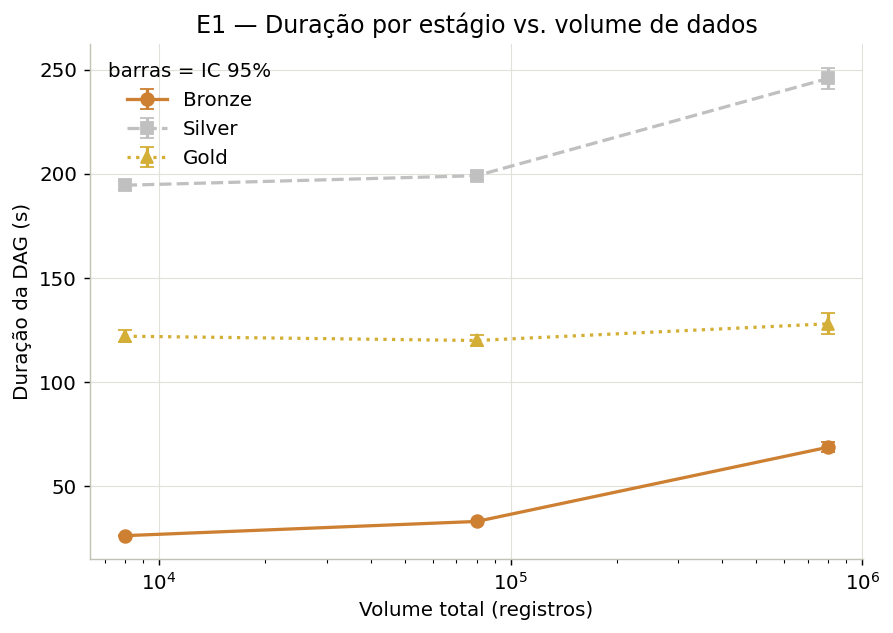

,dag,volume_total,mean,throughput_reg_s
0,dag_gold_refresh,8000,122.026417,65.559575
3,dag_ingestao_bronze,8000,26.206500,305.267777
6,dag_silver_transform,8000,194.553417,41.119812
1,dag_gold_refresh,80000,119.965917,666.856072
7,dag_silver_transform,80000,199.140417,401.726587
4,dag_ingestao_bronze,80000,33.033667,2421.771728
2,dag_gold_refresh,800000,127.982583,6250.850539
5,dag_ingestao_bronze,800000,68.705000,11643.985154
8,dag_silver_transform,800000,245.867083,3253.790581


In [5]:
if len(e1):
    fig, ax = plt.subplots(figsize=(7, 5))
    for dag in ["dag_ingestao_bronze", "dag_silver_transform", "dag_gold_refresh"]:
        d = e1_agg[e1_agg["dag"] == dag]
        if not len(d):
            continue
        # Barras de erro = IC 95% (t de Student); o std cru esta na tabela acima.
        ax.errorbar(
            d["volume_total"], d["mean"], yerr=d["ic95"].fillna(0),
            marker=MARCADORES_ESTAGIO[dag], linestyle=LINHAS_ESTAGIO[dag],
            color=CORES_ESTAGIO[dag], label=NOMES_ESTAGIO[dag],
            capsize=4, linewidth=1.8, markersize=7,
        )
    # x em log (volume varre decadas); y linear para NAO achatar visualmente a
    # diferenca entre estagios quase planos (Gold ~122s) e o crescimento do Bronze.
    ax.set_xscale("log")
    ax.set_xlabel("Volume total (registros)")
    ax.set_ylabel("Duração da DAG (s)")
    ax.set_title("E1 — Duração por estágio vs. volume de dados")
    ax.legend(frameon=False, title="barras = IC 95%")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig_e1_escalabilidade.png", dpi=200)
    plt.show()

    # Throughput derivado (registros/s = volume / duracao). A definicao e a
    # ressalva de leitura estao na celula markdown logo abaixo.
    e1_agg["throughput_reg_s"] = e1_agg["volume_total"] / e1_agg["mean"]
    display(e1_agg[["dag", "volume_total", "mean", "throughput_reg_s"]])
else:
    print("Sem dados de E1 ainda — rode o protocolo primeiro.")

### Análise

**Throughput** (vazão) é a **quantidade de trabalho por unidade de tempo**. Na tabela acima é `throughput_reg_s = volume_total / duração_média`, ou seja, **registros processados por segundo** — a métrica natural de "quão rápido o estágio processa dados".

Na Tabela 1, quando o volume cresce 100× (8k → 800k), a duração da **Silver** sobe só de ~195s para ~246s (1,3×) e a da **Gold** fica em ~120–128s (praticamente igual). Se a duração quase não muda com o volume, é porque a maior parte do tempo **não é gasta processando registros** — é um **custo fixo** pago a cada execução. Esse custo vem da estrutura da DAG: a Silver roda **8 tasks sequenciais** e a Gold **4**, e cada task faz um `spark-submit` que **sobe uma sessão/JVM Spark do zero** (alguns segundos), independentemente do volume. Assim, ~195–246s da Silver são dominados por 8× (partida de sessão + orquestração); só uma fatia pequena é processamento de fato. Como esse custo não depende do volume, a duração total fica ~constante → **regime dominado por overhead fixo**. O **Bronze** é o oposto (26 → 33 → 69s, 2,6×): lê 1 arquivo por lote do MinIO, então o trabalho escala 1:1 com o volume — é **limitado por dados**, não por overhead.

**A ressalva sobre o throughput (por que ele "engana" em Silver/Gold):**
Como `throughput = volume / duração`, se a duração é ~constante (Silver/Gold), então quanto maior o volume, **maior o throughput — quase automaticamente**. Mas esse crescimento **não** significa que o motor processa mais rápido: significa apenas que o **mesmo custo fixo foi diluído (amortizado) sobre mais registros**.

Por isso, em **Silver/Gold** o throughput alto no V3 reflete **amortização do overhead**, não vazão real de processamento. Só no **Bronze** — onde a duração de fato acompanha o volume — o throughput mede a **taxa de processamento verdadeira** (registros/s realmente lidos e escritos).

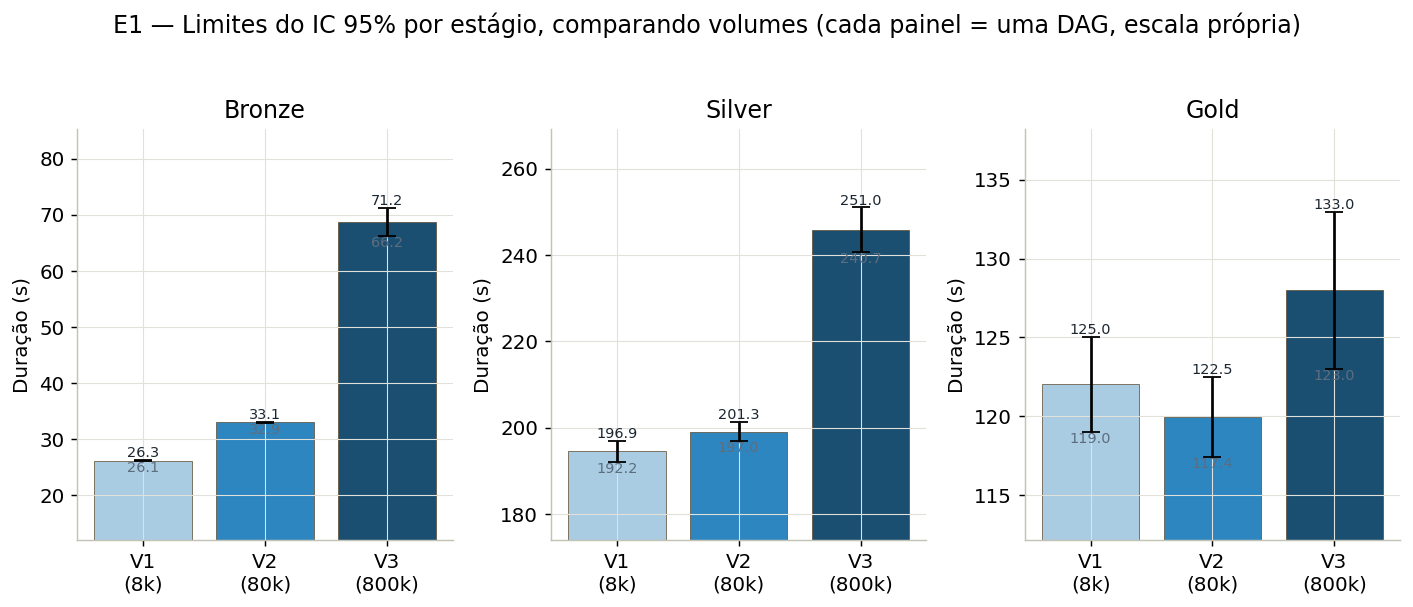

In [6]:
# Figura complementar E1: limites do IC 95% (inferior e superior) por estagio.
# Um painel por DAG (escala de y propria, pois os estagios operam em patamares
# muito diferentes); dentro de cada painel, os 3 volumes lado a lado para
# comparar como o intervalo de confianca se desloca com o volume.
if len(e1):
    ordem_dag = ["dag_ingestao_bronze", "dag_silver_transform", "dag_gold_refresh"]
    volumes = sorted(e1_agg["volume_total"].unique())
    rot_vol = {8000: "V1\n(8k)", 80000: "V2\n(80k)", 800000: "V3\n(800k)"}
    cores_vol = {8000: "#a9cce3", 80000: "#2e86c1", 800000: "#1b4f72"}

    fig, axes = plt.subplots(1, len(ordem_dag), figsize=(11, 4.5))
    for ax, dag in zip(axes, ordem_dag):
        d = e1_agg[e1_agg["dag"] == dag].set_index("volume_total").reindex(volumes)
        xs = np.arange(len(volumes))
        ax.bar(xs, d["mean"], yerr=d["ic95"], capsize=5,
               color=[cores_vol.get(v, "#888") for v in volumes], edgecolor="#5d4b2f", linewidth=0.4)
        for xi, m, ic in zip(xs, d["mean"], d["ic95"]):
            ax.annotate(f"{m + ic:.1f}", (xi, m + ic), ha="center", va="bottom", fontsize=8, color="#1b2631")
            ax.annotate(f"{m - ic:.1f}", (xi, m - ic), ha="center", va="top", fontsize=8, color="#5d6d7e")
        ax.set_xticks(xs); ax.set_xticklabels([rot_vol.get(v, str(v)) for v in volumes])
        ax.set_title(NOMES_ESTAGIO[dag])
        ax.set_ylabel("Duração (s)")
        lo = float((d["mean"] - d["ic95"]).min()); hi = float((d["mean"] + d["ic95"]).max())
        pad = (hi - lo) * 0.30 + 0.6
        ax.set_ylim(lo - pad, hi + pad)
    fig.suptitle("E1 — Limites do IC 95% por estágio, comparando volumes (cada painel = uma DAG, escala própria)", y=1.03)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig_e1_ic_por_estagio.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("Sem dados de E1 ainda.")

### Análise

Cada **painel** é uma DAG (escala de y própria, porque os estágios operam em patamares muito diferentes); dentro dele, as três barras são os volumes **V1/V2/V3 lado a lado**. A barra é a **média** e o *whisker* marca o **IC 95%** — os números anotados são o **limite inferior** (embaixo) e **superior** (em cima) do intervalo.

- **A regra de leitura:** se os intervalos de dois pontos **não se sobrepõem**, a diferença entre as médias é estatisticamente significativa (na prática, ao nível de ~5%) — são **diferentes**. Se os intervalos **se sobrepõem**, não há diferença distinguível a 95% de confiança: para o que este relatório precisa, tratam-se como **estatisticamente iguais**.
- **Largura do intervalo:** estreitíssima nos volumes menores (Bronze em V1/V2: IC de ±0,1s — quase um traço) e **alarga no V3** em todos os estágios (mais dados → um pouco mais de variabilidade entre execuções); ainda assim o maior intervalo (Silver@V3, ±5s) é pequeno perto da média (~246s).
- **Aplicando:** **Bronze** — os três IC **não se tocam** (~26 < 33 < 69s), então o crescimento com o volume é **real**. **Gold** — os IC **se sobrepõem** (~120–128s) e não há tendência monótona (V2 < V1 < V3): os três volumes são **estatisticamente iguais**, estágio insensível ao volume. **Silver** — V3 se separa com nitidez (**diferente**), enquanto V1 e V2 quase se tocam (diferença no limite).

*(É a mesma informação da coluna `IC 95% (±s)` da Tabela 1, agora visual e comparável por volume dentro de cada estágio.)*

Cada ponto é a média de 12 execuções; as barras de erro são o **IC 95%**. O eixo x está em escala log (o volume varre décadas) e o y é linear.

- **A leitura-chave é o formato das curvas:** as três são quase horizontais. Só o **Bronze** sobe de forma visível (~26 → 69s, **2,6x**) enquanto o volume cresce **100x**; **Silver e Gold** ficam praticamente planos (**1,3x**).
- **Curva plana = duração governada por custo fixo** (subir uma sessão Spark por task), não pelo volume de dados. Só o Bronze acompanha o volume porque lê 1 arquivo por lote no MinIO (mais objetos para listar/ler via S3A).
- **Ausência de "joelho" abrupto para cima** em qualquer estágio = não há degradação nem gargalo estrutural nessa faixa. A duração cresce *muito menos* que o volume em todos os pontos, então a pipeline nunca sai do regime dominado por overhead.

#### Análise detalhada

- Bronze: volume cresceu 100x (8,000 -> 800,000 registros) e a duração cresceu 2.62x (26s -> 69s).
- Silver: volume cresceu 100x (8,000 -> 800,000 registros) e a duração cresceu 1.26x (195s -> 246s).
- Gold: volume cresceu 100x (8,000 -> 800,000 registros) e a duração cresceu 1.05x (122s -> 128s).

O estágio mais sensível ao volume foi Bronze (2.62x de crescimento na duração para 100x de crescimento no volume). O menos sensível foi Gold (1.05x), praticamente plano.

Leitura: Silver e Gold ficam dominados pelo custo fixo de inicializar uma sessão Spark por task (8 tasks sequenciais na Silver, 4 na Gold) — esse custo não depende de quantos registros existem, só de quantas vezes uma JVM Spark precisa subir. Só o Bronze cresce de forma visível, provavelmente porque o número de arquivos JSON lidos do MinIO escala 1:1 com o volume (mais objetos para listar/ler via S3A), diferente de Silver/Gold onde o gargalo é orquestração, não volume de dados processado. Isso é o 'piso de overhead fixo' que o protocolo antecipava — é um achado honesto sobre o custo de coordenação da arquitetura em cargas pequenas, não um defeito da PoC.

Ressalva importante sobre o alcance de E1: como a duração cresce muito menos que o volume em TODOS os estágios (o mais sensível cresce só 2.6x para 100x de volume), nesses volumes a pipeline nunca sai do regime dominado por overhead fixo — nem no maior ponto o processamento de dados passa a dominar. Ou seja, E1 é evidência de que a arquitetura é ROBUSTA e PREVISÍVEL nesse regime (não quebra, não degrada abruptamente), mas não mede a escalabilidade do processamento em si, que só apareceria em volumes onde o custo de dados supere o de coordenação.

Nota estatística: cada ponto é a média de 12 repetições, com a duração agora cronometrada em milissegundos (date +%s.%N). A tabela reporta desvio-padrão (std) e IC 95% (utilizando os quantis da estatística t de Student) lado a lado: o std descreve a dispersão observada entre repetições; o IC 95% (barras da Figura E1) quantifica a incerteza da média corrigida pelo tamanho da amostra (n=12). Std muito baixo aqui reflete um ambiente menos variável (mesmo hardware, reset total entre reps), não mais um artefato de resolução do timer.

## 4. E2 — Speedup com paralelismo (Silver, volume fixo V3)

**Objetivo deste teste:** a Silver é a DAG mais pesada da pipeline (8 transformações
Bronze→Silver, uma por tipo de dado). E2 pergunta se ela usa mais recursos quando
mais recursos são oferecidos — um teste direto de que a escolha de Spark como
motor de processamento se justifica (ou não) nesse volume de trabalho.

**O que foi medido:** a duração da `dag_silver_transform` com volume fixo em V3
(800 mil registros, o maior de E1), variando `spark.cores.max`/`spark.executor.cores`
em 1 (baseline), 2 e 4 núcleos — 12 repetições por configuração. Esse é o desenho
**E2a (intra-job)**: cada um dos 8 `spark-submit` recebe mais núcleos, sem mudar a
estrutura da DAG (as 8 tasks continuam encadeadas sequencialmente).

**Expectativa declarada no protocolo:** speedup sublinear é esperado (a
carga é pequena para HPC), mas o valor exato — e principalmente o motivo do
resultado — é o que importa reportar, inclusive se a eficiência cair bastante.

In [7]:
e2 = duracoes[duracoes["tag"].str.match(r"^C\d+_rep\d+$") & (duracoes["dag"] == "dag_silver_transform")].copy() if not duracoes.empty else pd.DataFrame()

if len(e2):
    e2["cores"] = e2["tag"].str.extract(r"^C(\d+)_rep\d+$").astype(int)
    e2_agg = e2.groupby("cores")["segundos"].agg(["mean", "std", "count"]).reset_index().sort_values("cores")
    # Erro-padrao e IC 95% (t de Student) da duracao, ao lado do std cru.
    e2_agg = add_ic95(e2_agg)

    t_baseline = e2_agg.loc[e2_agg["cores"] == 1, "mean"]
    sem_baseline = e2_agg.loc[e2_agg["cores"] == 1, "sem"]
    if len(t_baseline):
        t_baseline = t_baseline.iloc[0]
        sem_baseline = sem_baseline.iloc[0]
        e2_agg["speedup"] = t_baseline / e2_agg["mean"]
        e2_agg["eficiencia"] = e2_agg["speedup"] / e2_agg["cores"]
        # IC 95% do speedup (razao T(C1)/T(CN)): propagacao de erro relativo,
        # (sem/mean) somado em quadratura entre baseline e ponto atual.
        rel = np.sqrt((sem_baseline / t_baseline) ** 2 + (e2_agg["sem"] / e2_agg["mean"]) ** 2)
        e2_agg["speedup_ic95"] = e2_agg["count"].map(t95) * e2_agg["speedup"] * rel
    display(e2_agg)
else:
    print("Sem dados de E2 ainda.")


,cores,mean,std,count,sem,ic95,speedup,eficiencia,speedup_ic95
0,1,245.164333,3.376448,12,0.974697,2.145307,1.000000,1.000000,0.012375
1,2,226.445500,3.346844,12,0.966151,2.126498,1.082664,0.541332,0.013897
2,4,213.146083,2.810788,12,0.811405,1.785902,1.150217,0.287554,0.013935


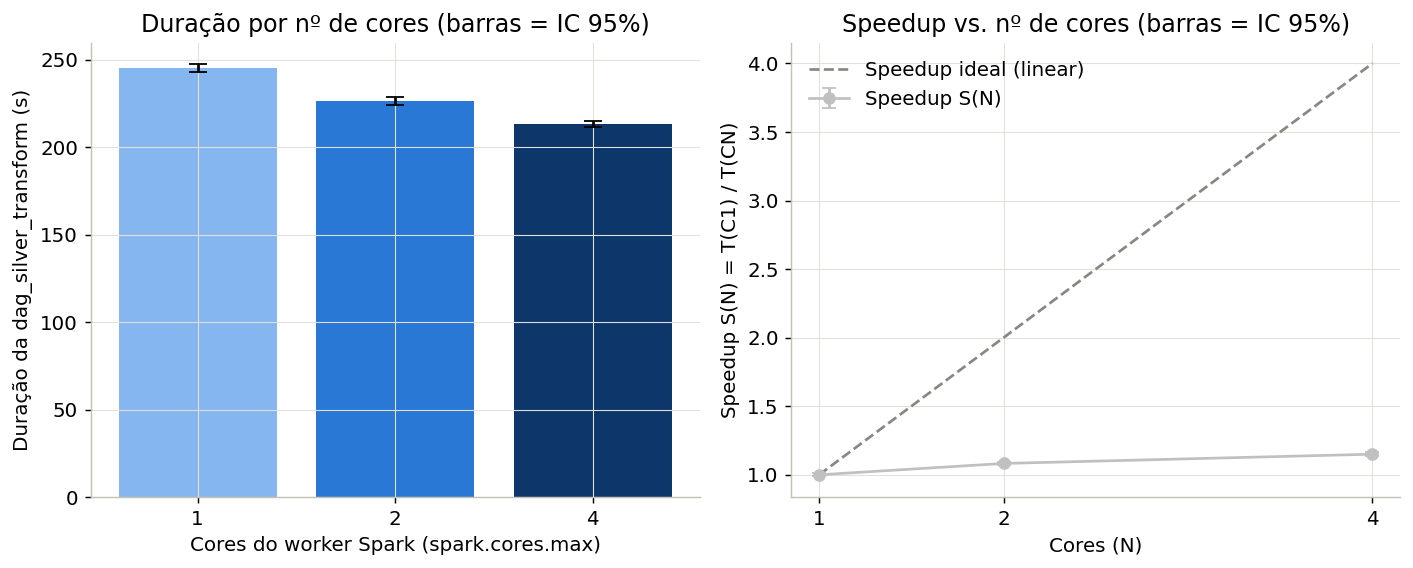

In [8]:
if len(e2):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    ax = axes[0]
    cores_ordenados = sorted(e2_agg["cores"].unique())
    # Barras de erro = IC 95% (t de Student); std cru esta na tabela acima.
    ax.bar(
        [str(c) for c in cores_ordenados],
        [e2_agg.set_index("cores").loc[c, "mean"] for c in cores_ordenados],
        yerr=[e2_agg.set_index("cores").loc[c, "ic95"] for c in cores_ordenados],
        color=[RAMPA_CORES_E2.get(c, COR_SILVER) for c in cores_ordenados],
        capsize=5,
    )
    ax.set_xlabel("Cores do worker Spark (spark.cores.max)")
    ax.set_ylabel("Duração da dag_silver_transform (s)")
    ax.set_title("Duração por nº de cores (barras = IC 95%)")

    ax2 = axes[1]
    if "speedup" in e2_agg.columns:
        ax2.errorbar(
            e2_agg["cores"], e2_agg["speedup"],
            yerr=e2_agg["speedup_ic95"].fillna(0),
            marker="o", color=COR_SILVER, capsize=4, label="Speedup S(N)",
        )
        ax2.plot(e2_agg["cores"], e2_agg["cores"], linestyle="--", color="#898781", label="Speedup ideal (linear)")
        ax2.set_xlabel("Cores (N)")
        ax2.set_ylabel("Speedup S(N) = T(C1) / T(CN)")
        ax2.set_title("Speedup vs. nº de cores (barras = IC 95%)")
        ax2.legend(frameon=False)
        ax2.set_xticks(sorted(e2_agg["cores"].unique()))

    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig_e2_speedup.png", dpi=200)
    plt.show()
else:
    print("Sem dados de E2 ainda — rode o protocolo primeiro.")


In [9]:
tarefas_agg = None
if len(tasks):
    tarefas_e2 = tasks[tasks["tag"].str.match(r"^C\d+_rep\d+$") & (tasks["dag"] == "dag_silver_transform")].copy()
    if len(tarefas_e2):
        tarefas_e2["cores"] = tarefas_e2["tag"].str.extract(r"^C(\d+)_rep\d+$").astype(int)
        tarefas_agg = tarefas_e2.groupby(["cores", "task_id"])["duration_s"].mean().unstack("task_id")
        display(tarefas_agg.round(1))
    else:
        print("Sem duracoes por task para E2 ainda.")

task_id,silver_gps,silver_material,silver_obstaculo,silver_paf,silver_pessoal,silver_relt_intel,silver_seg_area,silver_sensor
cores,,,,,,,,
1,15.5,12.5,13.0,13.4,13.3,13.1,13.7,12.5
2,13.5,11.9,12.0,12.5,12.4,12.2,12.2,11.5
4,12.1,11.0,11.0,11.1,11.0,11.1,11.0,10.8


**A métrica de speedup** é a definição clássica de computação paralela/HPC — **S(N) = T(1) / T(N)**, a razão entre o tempo com a configuração baseline (1 núcleo) e o tempo com N núcleos (calculada na célula de agregação de E2 como `T(C1) / T(CN)`, com T = duração média das 12 repetições). É a mesma métrica associada à **Lei de Amdahl** (Amdahl, 1967) e padrão em textos de HPC (ex.: Grama et al., *Introduction to Parallel Computing*, 2003).

**Painel esquerdo — Duração por nº de cores (barras):** a altura cai 245s → 226s → 213s (1 → 2 → 4 núcleos). Mais núcleos reduzem o tempo, de forma monótona, mas **pouco** (~13% com 4× os núcleos). As barras de erro (IC 95%, ±~2s) não se sobrepõem, então cada redução é real, não ruído.

**Painel direito — Speedup S(N) vs. nº de cores (linha cheia) contra o ideal linear (tracejado):**

- A reta tracejada é o **speedup ideal, S(N) = N**. Ela é o *ideal* porque representa uma carga perfeitamente paralelizável e sem overhead: com N vezes o recurso, o trabalho terminaria N vezes mais rápido (tempo → T(1)/N). É o limite teórico superior — na prática quase nunca alcançado, porque a **fração serial** do trabalho (Lei de Amdahl: S(N) ≤ 1/s), o **custo de coordenação** e a **contenção de recursos** sempre puxam a curva medida para baixo dela.
- A curva **medida** (1,00 → 1,08 → **1,15**) fica muito abaixo da diagonal, e a distância até ela **cresce** com N. Essa distância é a perda de eficiência: a 4 núcleos o ideal seria 4×, mas o medido é 1,15× (eficiência 29%).
- **A forma conta a história:** um speedup quase plano ao lado de uma diagonal íngreme é a assinatura de uma carga **dominada por overhead** (fração paralelizável pequena). Dar mais núcleos a cada `spark-submit` não ajuda porque o tempo de cada task é gasto subindo a sessão Spark, não processando.

#### Análise detalhada

- 1 core(s): 245.2s (±2.1 IC95) | speedup 1.00x (±0.01) | eficiência 100%
- 2 core(s): 226.4s (±2.1 IC95) | speedup 1.08x (±0.01) | eficiência 54%
- 4 core(s): 213.1s (±1.8 IC95) | speedup 1.15x (±0.01) | eficiência 29%

Com 4 núcleos o speedup medido foi de apenas 1.15x (IC 95% ±0.01; eficiência 29% do ideal linear). 
O IC 95% do speedup a 4 núcleos ([1.14, 1.16]) não inclui 1.0, então há ganho real, ainda que pequeno — distinção que só 12 repetições permitem afirmar.
Olhando o detalhamento por task: a duração média de cada uma das 8 tasks individuais varia pouco entre 1 e 4 núcleos (11.1s a 13.4s), porque cada `spark-submit` paga um custo fixo de subida de JVM/sessão Spark que não encolhe com mais núcleos — esse custo domina o tempo de cada task nesse volume de dados, não o processamento em si.

Leitura: o speedup baixo não é sinal de que Spark foi má escolha, é sinal de que o gargalo desta DAG é orquestração (8 spark-submit sequenciais, cada um pagando startup fixo), não paralelismo de dados dentro de cada job — 'spark.cores.max' só acelera a fração de tempo gasta processando dados, que é pequena perto do overhead de sessão neste volume.

## 5. Tabela descritiva — contagens, deduplicação, tamanho e snapshots

**Objetivo desta tabela:** a Seção 5 do artigo original descrevia a arquitetura mas
não trazia nenhum número sobre o que ela de fato produz — quantos registros
sobrevivem a cada camada, se a deduplicação por chave natural funciona, quanto
espaço as tabelas ocupam e se o versionamento Iceberg (snapshots, time travel) está
realmente acontecendo. Esta tabela fecha essa lacuna.

In [10]:
if len(contagens):
    tag_ref = sorted([t for t in contagens["tag"].unique() if t.startswith("V3_")])
    tag_ref = tag_ref[-1] if tag_ref else contagens["tag"].iloc[-1]
    print(f"Usando tag de referencia: {tag_ref}")

    c = contagens[contagens["tag"] == tag_ref].copy()
    bronze_total = c[c["zona"] == "bronze"]["registros"].sum()
    silver = c[c["zona"] == "silver"].copy()
    silver = silver.rename(columns={"tabela": "tipo", "registros": "registros_silver"})

    tam = tamanhos[tamanhos["tag"] == tag_ref].copy()
    tam["tipo"] = tam["tabela"].str.replace("silver.", "", regex=False)

    snap = snapshots[snapshots["tag"] == tag_ref].copy()
    snap["tipo"] = snap["tabela"].str.replace("silver.", "", regex=False)

    # A Bronze e uma unica tabela mista ('dados') com os 8 tipos repartidos igualmente
    # pelo gerador (mesmo n de registros por tipo). O denominador honesto da dedup de
    # CADA tipo e a fatia da Bronze daquele tipo (total / n_tipos), NAO o total da Bronze:
    # usar o total inflaria toda taxa em ~1-1/n_tipos so pelo efeito da mistura.
    n_tipos = silver["tipo"].nunique()
    registros_bronze_tipo = bronze_total / n_tipos

    desc = silver.merge(tam[["tipo", "n_arquivos", "tamanho_mb"]], on="tipo", how="left")
    desc = desc.merge(snap[["tipo", "n_snapshots"]], on="tipo", how="left")
    desc["registros_bronze_tipo"] = registros_bronze_tipo
    desc["taxa_dedup_pct"] = (1 - desc["registros_silver"] / desc["registros_bronze_tipo"]) * 100
    desc = desc[["tipo", "registros_bronze_tipo", "registros_silver", "taxa_dedup_pct", "n_arquivos", "tamanho_mb", "n_snapshots"]]
    display(desc.round(2))
    print(
        f"\n(Bronze total = {int(bronze_total):,} registros, repartidos entre {n_tipos} tipos "
        f"=> {int(registros_bronze_tipo):,} por tipo, usado como denominador da dedup.)"
    )
    desc.to_csv(RESULT_DIR / f"tabela_descritiva_{tag_ref}.csv", index=False)
else:
    desc = pd.DataFrame()
    print("Sem dados de contagens ainda.")

Usando tag de referencia: V3_rep9


,tipo,registros_bronze_tipo,registros_silver,taxa_dedup_pct,n_arquivos,tamanho_mb,n_snapshots
0,gps,100000.0,100000,0.0,7,2.51,2
1,sensor,100000.0,105,99.9,7,0.04,2
2,relt_intel,100000.0,100000,0.0,7,6.36,2
3,paf,100000.0,100000,0.0,7,4.22,2
4,obstaculo,100000.0,100000,0.0,7,4.42,2
5,seg_area,100000.0,100000,0.0,7,4.28,2
6,pessoal,100000.0,100000,0.0,7,3.04,2
7,material,100000.0,100000,0.0,7,0.95,2



(Bronze total = 800,000 registros, repartidos entre 8 tipos => 100,000 por tipo, usado como denominador da dedup.)


### O que esses resultados mostram

- Compare **Bronze (reg.)** com **Silver (reg.)** por tipo: caírem juntos = **deduplicação real por chave natural** (caso do `sensor`: 100k → 105, **99,9%**); ficarem iguais = chave única por execução, nada a colapsar (dedup ≈ 0%, esperado pelo modelo de dados).
- **Snapshots = 2** por tabela confirma que cada execução da Silver gera uma nova versão Iceberg — a base do *time travel*.
- **Arquivos / Tamanho (MB)** mostram a materialização física de cada tabela Silver (o `sensor`, com 105 linhas, ocupa só 0,04 MB; os densos passam de 6 MB).

#### Análise detalhada

Leitura da coluna 'taxa_dedup_pct': o denominador agora é a fatia da Bronze de cada tipo (total / n_tipos), então a taxa reflete deduplicação real por tipo, não o artefato de misturar 8 tipos numa Bronze só. Taxa ~0% = o tipo usa identificador gerado por execução (sempre único), então o MERGE INTO da Silver não tem o que colapsar; taxa alta = deduplicação real por chave natural.

'sensor' se destaca com 99.9% de dedup — 100000 registros brutos do tipo na Bronze colapsaram para só 105 linhas na Silver. Isso é dedup real por chave natural: esse tipo usa um identificador de entidade física com cardinalidade baixa e fixa (poucas dezenas/centenas de valores possíveis), então o MERGE INTO está colapsando leituras repetidas da mesma entidade ao longo do tempo. Os demais tipos (dedup ≈ 0%) usam identificador gerado por execução (sempre único), então não deduplicam — comportamento esperado do modelo de dados, não um defeito.

Tamanho físico e nº de arquivos (7-7 arquivos, 0.04-6.37 MB por tabela) e nº de snapshots (2-2 por tabela) confirmam que cada execução da Silver gera um snapshot Iceberg novo — o versionamento que sustenta o time travel está ativo (aqui observado em poucas execuções; a acumulação de snapshots ao longo de mais runs é o que a dag_iceberg_maintenance posteriormente compacta).

## 6. Tabelas consolidadas

Esta seção reúne, num só lugar, os dados dos dois experimentos e da descritiva em
**tabelas formatadas** (cabeçalhos em português e unidades explícitas)

In [11]:
# Tabelas consolidadas: reformata E1, E2 e a descritiva com cabecalhos em
# portugues + unidades, e exporta CSV + LaTeX (resultados/tabelas/) para reuso
# direto no artigo. Numeros vem dos mesmos DataFrames ja calculados acima.
TAB_DIR = RESULT_DIR / "tabelas"
TAB_DIR.mkdir(exist_ok=True)

def _exporta(df, nome):
    df.to_csv(TAB_DIR / f"{nome}.csv", index=False)
    try:
        (TAB_DIR / f"{nome}.tex").write_text(
            df.to_latex(index=False, float_format="%.2f")
        )
    except Exception as e:  # pandas antigo/sem jinja2: nao aborta o relatorio
        print(f"(LaTeX de {nome} pulado: {e})")

nrep = int(e1_agg["count"].max()) if len(e1) else "?"

# --- Tabela 1: E1 (escalabilidade) ---
if len(e1):
    tab_e1 = e1_agg.copy()
    tab_e1["Estágio"] = tab_e1["dag"].map(NOMES_ESTAGIO)
    tab_e1 = (
        tab_e1.rename(columns={
            "volume_total": "Volume (reg.)", "count": "n", "mean": "Média (s)",
            "std": "Desv.-pad. (s)", "ic95": "IC 95% (±s)",
        })[["Estágio", "Volume (reg.)", "n", "Média (s)", "Desv.-pad. (s)", "IC 95% (±s)"]]
        .sort_values(["Estágio", "Volume (reg.)"]).round(2).reset_index(drop=True)
    )
    print(f"Tabela 1 — E1: duração por estágio e volume ({nrep} reps/ponto)")
    display(tab_e1)
    _exporta(tab_e1, "tab_e1_escalabilidade")

# --- Tabela 2: E2 (speedup) ---
if len(e2) and "speedup" in e2_agg.columns:
    tab_e2 = e2_agg.copy()
    tab_e2["Eficiência (%)"] = tab_e2["eficiencia"] * 100
    tab_e2 = (
        tab_e2.rename(columns={
            "cores": "Cores", "count": "n", "mean": "Média (s)",
            "std": "Desv.-pad. (s)", "ic95": "IC 95% (±s)",
            "speedup": "Speedup", "speedup_ic95": "Speedup IC 95% (±)",
        })[["Cores", "n", "Média (s)", "Desv.-pad. (s)", "IC 95% (±s)",
            "Speedup", "Speedup IC 95% (±)", "Eficiência (%)"]]
        .round(2).reset_index(drop=True)
    )
    print(f"\nTabela 2 — E2: speedup da dag_silver_transform em V3 (800k reg., {nrep} reps/ponto)")
    display(tab_e2)
    _exporta(tab_e2, "tab_e2_speedup")

# --- Tabela 3: descritiva por tipo (reusa desc da Secao 5) ---
if len(desc):
    tab_desc = desc.rename(columns={
        "tipo": "Tipo", "registros_bronze_tipo": "Bronze (reg.)",
        "registros_silver": "Silver (reg.)", "taxa_dedup_pct": "Dedup (%)",
        "n_arquivos": "Arquivos", "tamanho_mb": "Tamanho (MB)", "n_snapshots": "Snapshots",
    }).round(2).reset_index(drop=True)
    print("\nTabela 3 — Descritiva por tipo (tag V3 de referência)")
    display(tab_desc)
    _exporta(tab_desc, "tab_descritiva")

print(f"\nTabelas exportadas (CSV + LaTeX) em: {TAB_DIR}")


Tabela 1 — E1: duração por estágio e volume (12 reps/ponto)


,Estágio,Volume (reg.),n,Média (s),Desv.-pad. (s),IC 95% (±s)
0,Bronze,8000,12,26.21,0.13,0.08
1,Bronze,80000,12,33.03,0.15,0.09
2,Bronze,800000,12,68.70,3.95,2.51
3,Gold,8000,12,122.03,4.74,3.01
4,Gold,80000,12,119.97,4.02,2.56
5,Gold,800000,12,127.98,7.85,4.98
6,Silver,8000,12,194.55,3.73,2.37
7,Silver,80000,12,199.14,3.38,2.15
8,Silver,800000,12,245.87,8.15,5.18



Tabela 2 — E2: speedup da dag_silver_transform em V3 (800k reg., 12 reps/ponto)


,Cores,n,Média (s),Desv.-pad. (s),IC 95% (±s),Speedup,Speedup IC 95% (±),Eficiência (%)
0,1,12,245.16,3.38,2.15,1.00,0.01,100.00
1,2,12,226.45,3.35,2.13,1.08,0.01,54.13
2,4,12,213.15,2.81,1.79,1.15,0.01,28.76



Tabela 3 — Descritiva por tipo (tag V3 de referência)


,Tipo,Bronze (reg.),Silver (reg.),Dedup (%),Arquivos,Tamanho (MB),Snapshots
0,gps,100000.0,100000,0.0,7,2.51,2
1,sensor,100000.0,105,99.9,7,0.04,2
2,relt_intel,100000.0,100000,0.0,7,6.36,2
3,paf,100000.0,100000,0.0,7,4.22,2
4,obstaculo,100000.0,100000,0.0,7,4.42,2
5,seg_area,100000.0,100000,0.0,7,4.28,2
6,pessoal,100000.0,100000,0.0,7,3.04,2
7,material,100000.0,100000,0.0,7,0.95,2



Tabelas exportadas (CSV + LaTeX) em: resultados/tabelas


## 7. Síntese e discussão geral

**E1 (escalabilidade):** em 2 ordens de grandeza de volume (8×10³→8×10⁵ registros), a arquitetura não quebra nem degrada abruptamente — o estágio mais sensível ao volume (Bronze, leitura/escrita de arquivos) cresceu 2.6x, enquanto Silver/Gold ficaram essencialmente planos (1.3x), dominados por overhead fixo de orquestração. Como a duração cresce muito menos que o volume em todos os estágios, nesses volumes a pipeline permanece no regime dominado por overhead: E1 é evidência de que a arquitetura é robusta e previsível nesse regime, não de escalabilidade linear do processamento (que exigiria volumes maiores). O comportamento contrário (crescimento explosivo ou não-linear) teria sido um sinal de alerta que este experimento não encontrou.

**E2 (paralelismo):** o speedup com mais núcleos foi modesto (1.15x ± 0.01 com 4 núcleos) porque o gargalo da Silver é orquestração (8 spark-submit sequenciais, cada um pagando startup fixo de sessão), não processamento paralelo de dados. Reportar esse número honesto — com seu IC 95%, em vez de omiti-lo ou escolher só a configuração mais favorável — é consistente com a prática de HPC: eficiência baixa em cargas pequenas dominadas por overhead de coordenação é esperado, não um defeito a esconder.

**Limitações:** hardware único (computador pessoal, não cluster — por isso o relatório reporta grandezas relativas), medição restrita ao paralelismo intra-job (mais núcleos por spark-submit), não entre as 8 tasks, e 12 repetições por ponto. A duração é cronometrada em milissegundos e a incerteza da média é reportada como IC 95% (t de Student) ao lado do desvio-padrão; ainda assim, num ambiente tão determinístico (hardware único, reset total entre reps) a dispersão observada é pequena, então o IC reflete mais a estabilidade do ambiente do que variabilidade intrínseca da carga.

## 8. Referências

- AMDAHL, G. M. Validity of the single processor approach to achieving large scale computing capabilities. In: SPRING JOINT COMPUTER CONFERENCE, 1967, Atlantic City. AFIPS Conference Proceedings. Reston: AFIPS Press, 1967. v. 30, p. 483-485.
- GRAMA, A.; GUPTA, A.; KARYPIS, G.; KUMAR, V. Introduction to Parallel Computing. 2. ed. Boston: Addison-Wesley, 2003.
